This is code that:
1. Generates a matrix with modular interactions, one with hub-node interactions, and one with random interactions (functions from metaCommunityMx.py)
2. Samples uniformly at random some species from the matrices, runs deterministic GLV, and stores simulated data
3. Calculates co-occurrence matrix as covariance between abundance vectors
    also plots and looks at proportions of links within and between clusters
4. Runs a clustering algorith to find clusters in the matrix
5. Tests to see if the clusters are similar to the original modules

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import networkx as nx
from sklearn import metrics

import metaCommunityMx
import community_sim
import metrics_and_plotting
import run_cooccurrence
reload(metaCommunityMx)
reload(community_sim)
reload(metrics_and_plotting)
reload(run_cooccurrence)

import pickle, os
os.makedirs('figure_data', exist_ok=True)

1. Generate matrices

In [198]:
# for random matrix
interactFactor = 1/5 # 1/3 1/5 1/10
nSpec = 100
pPositive = 0.5
pInteract = 0.05 # this is only used for random matrix
#pInteract = 0.1735 # this makes the same number of interactions as modular mx with nSpec = 100, nModules = 5, pWithinMod = 0.9, pBetweenMod = 0.001

# for modular matrix or hub mx
nModules = 10
matchingParms = metaCommunityMx.hubMxMatching(nSpec, nModules, pInteractRandom = pInteract)
pWithinMod = matchingParms['pWithinMod'] # 0.9
pBetweenMod = matchingParms['pBetweenMod'] # 0.001

assert pWithinMod > pBetweenMod

# hub mx
pWithinModHub = matchingParms['pWithinModHub'] # 0.01
pBetweenModHub = matchingParms['pBetweenModHub'] # 0.001
pHub = matchingParms['pHub'] # 0.95

assert pHub > pWithinModHub
assert pHub > pBetweenModHub

# parms for GLV sim
#alpha = 0.001
alpha = np.random.uniform(low = 0.0007, high = 0.002, size = nSpec)
interactStren = np.mean(alpha) * interactFactor
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))
b_200 = np.ones(200) - np.random.uniform(low = 0, high = .1, size = (200))

zeroMx = np.zeros(shape = (nSpec, nSpec))
randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)
modMx = metaCommunityMx.generateModularMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinMod, pBetweenMod = pBetweenMod, nModules = nModules)
hubMx = metaCommunityMx.generateHubMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinModHub, pBetweenMod = pBetweenModHub, nModules = nModules, pHub = pHub)

modMx_disconn = metaCommunityMx.generateModularMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = 1, pBetweenMod = 0, nModules = 2)
hubMx_perf = metaCommunityMx.generateHubMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = 200, pWithinMod = 0, pBetweenMod = 0, nModules = 20, pHub = 1)


In [199]:
# calculating expected number of links in each network
totalLinks = nSpec**2 - nSpec
modSize = nSpec // nModules
linksWithin = nModules * (modSize**2 - modSize)

E_edges_rand = pInteract * totalLinks
E_edges_mod = pWithinMod * linksWithin + pBetweenMod * (totalLinks - linksWithin)
E_edges_hub = pWithinModHub * linksWithin + pBetweenModHub * (totalLinks - linksWithin) + pHub * nModules * (modSize - 1)

print('Expected # edges in random mx:')
print(E_edges_rand)
print('actual number of edges:')
print(sum(sum(randMx != 0)))
print()

print('Expected # edges in modular mx:')
print(E_edges_mod)
print('actual number of edges:')
print(sum(sum(modMx != 0)))
print()

print('Expected # edges in hub mx:')
print(E_edges_hub)
print('actual number of edges:')
print(sum(sum(hubMx != 0)))
print()



Expected # edges in random mx:
495.0
actual number of edges:
462

Expected # edges in modular mx:
495.00000000000006
actual number of edges:
498

Expected # edges in hub mx:
498.7155963302753
actual number of edges:
570



2. Samples some species uniformly at random from the matrices, runs deterministic GLV, and stores simulated data

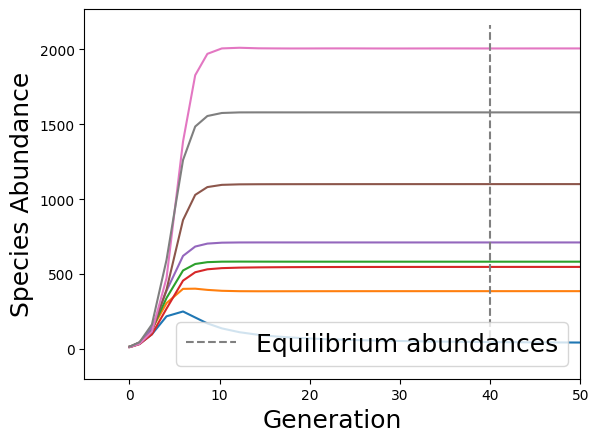

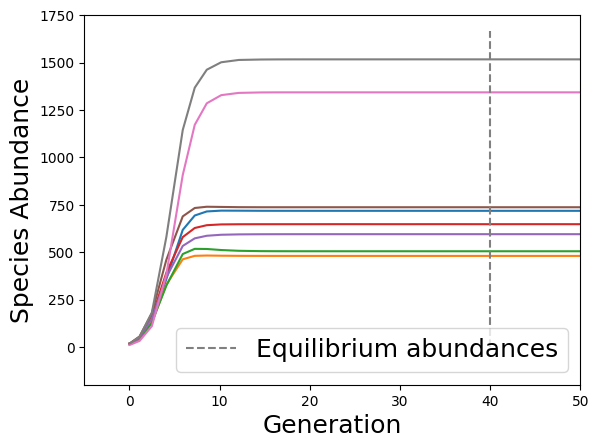

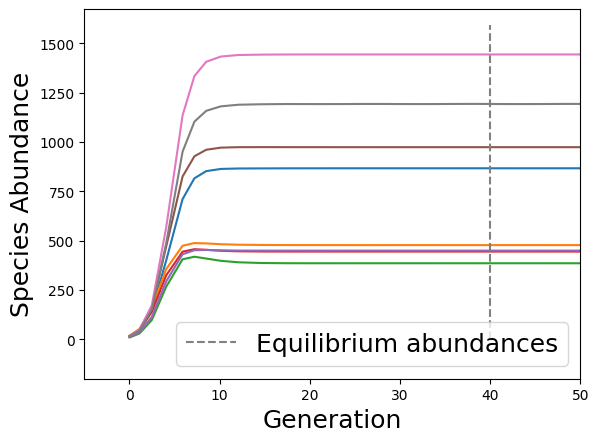

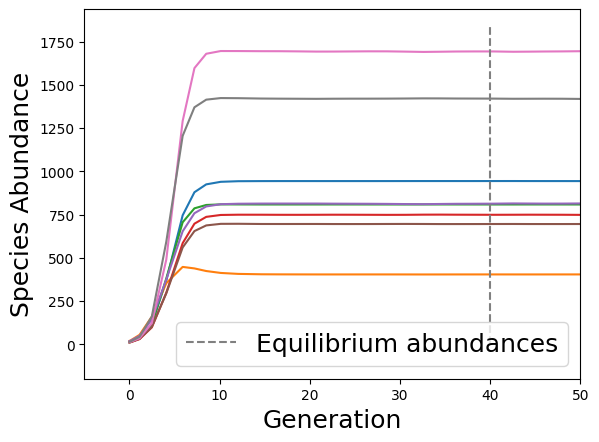

In [242]:

for ii in range(4):
    randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

    b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))

    sol = community_sim.run_communityDynamics(a = randMx, b = b, alpha = alpha, tmax = 100, y0 = None)

    plotSpec = 8
    for i in range(plotSpec):
        plt.plot(sol.t, sol.y[i])
    plt.xlabel(f'Generation', fontsize = 18)
    plt.ylabel(f'Species Abundance', fontsize = 18)
    plt.vlines(x = 40, ymin = 0, ymax = np.max(sol.y[0:plotSpec]) + 150, linestyles="dashed", colors="gray", label = "Equilibrium abundances")
    plt.xlim(right = 50)
    plt.ylim(bottom = -199)
    plt.legend(fontsize = 18, loc = 'lower right')

    with open(f'figure_data/rid_species_dynamics{ii}.pkl', 'wb') as f:
        pickle.dump({'sol_t': sol.t, 'sol_y': sol.y, 'plotSpec': plotSpec}, f)

    plt.show()

    abds_end = sol.y[:, -1]
    abds_end_m1 = sol.y[:, -2]

    # print(np.round(abds_end, 0)[1:10])
    # print(np.round(abds_end_m1, 0)[1:10])

    # print(randMx[1:10,1:10])

In [ ]:

zero_res = community_sim.simulate_coOccurrence(samplesize, numtrials, a = zeroMx, b = b, alpha = alpha, tmax = 100, y0 = None)
null_coAbd = np.round(zero_res[0], 0)

rand_res = community_sim.simulate_coOccurrence(samplesize, numtrials, a = randMx, b = b, alpha = alpha, tmax = 100, y0 = None)
rand_coAbd = np.round(rand_res[0], 0)
print("rand_coAbd")
print(rand_coAbd)
print(np.sum(rand_coAbd != 0))
print(np.max(rand_coAbd))

mod_res = community_sim.simulate_coOccurrence(samplesize, numtrials, a = modMx, b = b, alpha = alpha, tmax = 100, y0 = None)
mod_coAbd = np.round(mod_res[0], 0)
print("mod_coAbd")
print(mod_coAbd)
print(np.sum(mod_coAbd != 0))
print(np.max(mod_coAbd))

hub_res = community_sim.simulate_coOccurrence(samplesize, numtrials, a = hubMx, b = b, alpha = alpha, tmax = 100, y0 = None)
hub_coAbd = np.round(hub_res[0], 0)
print("hub_coAbd")
print(hub_coAbd)
print(np.sum(hub_coAbd != 0))
print(np.max(hub_coAbd))

rand_coAbd
[[   0.    0.  750. ...  869.    0. 1215.]
 [ 920.  542.    0. ...  804.  632.    0.]
 [1415.  552.    0. ...  720.  690.    0.]
 ...
 [   0.  532.    0. ...  760.  470.    0.]
 [ 756.    0.    0. ...  632.  463.    0.]
 [   0.  559.  373. ...  635.    0. 1215.]]
25000
1958.0
mod_coAbd
[[   0.    0.  772. ...    0.    0.  622.]
 [   0.    0.  893. ...    0.  504. 1465.]
 [ 864.    0.    0. ...    0.  408.  609.]
 ...
 [ 847.  457.  712. ...    0.  641.    0.]
 [   0.    0.  920. ...  498.  440.    0.]
 [   0.  435.    0. ...  420.  509. 1083.]]
24989
2109.0
hub_coAbd
[[1146.  541.    0. ...  922.    0. 1211.]
 [ 669.  582.    0. ...    0.    0.    0.]
 [   0.  483.  496. ...    0.  361.    0.]
 ...
 [ 924.  756.  743. ...  940.  753.    0.]
 [ 961.    0.  764. ... 1224.    0. 1116.]
 [1066.    0.    0. ...    0.    0.    0.]]
24986
2510.0


3. Calculates co-occurrence matrix as covariance between abundance vectors

In [202]:
# covariance of species abundances
covar_null = np.cov(null_coAbd, rowvar = False)
covar_rand = np.cov(rand_coAbd, rowvar = False)
covar_mod = np.cov(mod_coAbd, rowvar = False)
#covar_mod_disconn = np.cov(mod_coAbd_disconn, rowvar = False)
covar_hub = np.cov(hub_coAbd, rowvar = False)
#covar_hub_perf = np.cov(hub_coAbd_perf, rowvar = False)

# Pearson product-moment correlation coefficients
pearson_null = np.corrcoef(null_coAbd, rowvar = False)
pearson_rand = np.corrcoef(rand_coAbd, rowvar = False)
pearson_mod = np.corrcoef(mod_coAbd, rowvar = False)
#pearson_mod_disconn = np.corrcoef(mod_coAbd_disconn, rowvar = False)
pearson_hub = np.corrcoef(hub_coAbd, rowvar = False)
#pearson_hub_perf = np.corrcoef(hub_coAbd_perf, rowvar = False)

print(pearson_rand[1:10,1:10])

[[ 1.         -0.01041645 -0.03947813 -0.02949091 -0.06113741 -0.05077365
   0.06476134 -0.00273083 -0.13091675]
 [-0.01041645  1.         -0.06839119  0.03289323  0.00190265  0.02881048
   0.05702284 -0.0347042  -0.06406316]
 [-0.03947813 -0.06839119  1.          0.07362609 -0.01633664 -0.11594993
   0.01643714 -0.03895746 -0.02990726]
 [-0.02949091  0.03289323  0.07362609  1.         -0.03876384  0.03757731
  -0.0773099  -0.00716786 -0.00801934]
 [-0.06113741  0.00190265 -0.01633664 -0.03876384  1.         -0.04021243
  -0.01260642 -0.09998637  0.07215246]
 [-0.05077365  0.02881048 -0.11594993  0.03757731 -0.04021243  1.
  -0.04974792  0.09361574  0.12755311]
 [ 0.06476134  0.05702284  0.01643714 -0.0773099  -0.01260642 -0.04974792
   1.          0.02567354 -0.09158444]
 [-0.00273083 -0.0347042  -0.03895746 -0.00716786 -0.09998637  0.09361574
   0.02567354  1.         -0.08784429]
 [-0.13091675 -0.06406316 -0.02990726 -0.00801934  0.07215246  0.12755311
  -0.09158444 -0.08784429  1. 

3.1. plots original and co-occurrence networks side by side, based on cutoff at 95th percentile of null distribution. (not too useful with a lot of species)

cutoff_null
(np.float64(-0.1260611873011524), np.float64(0.10589263515609013))


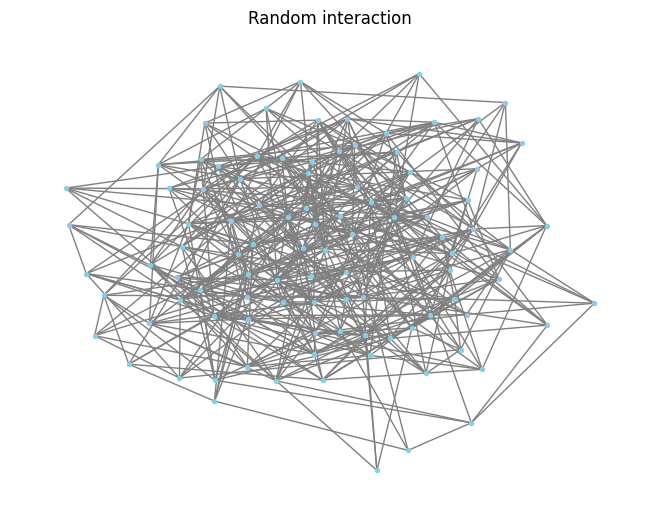

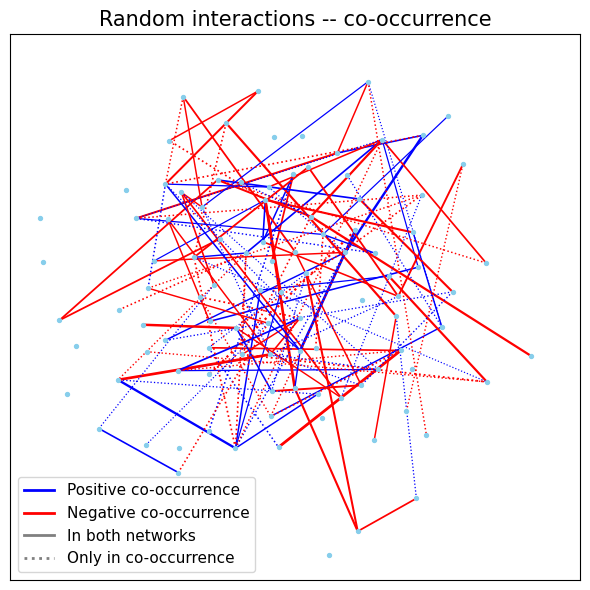

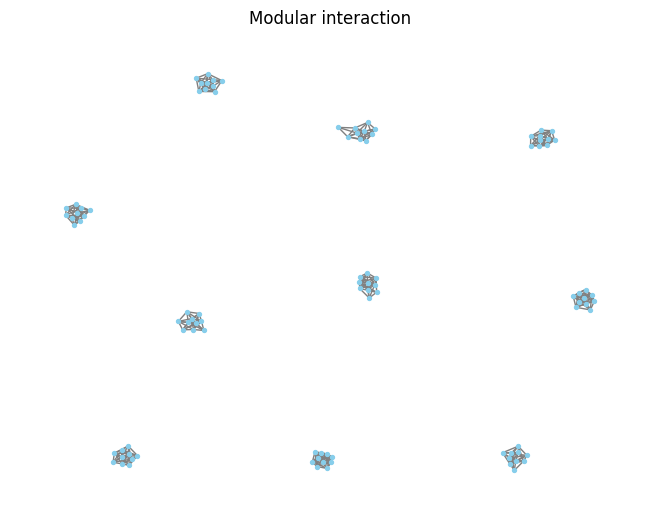

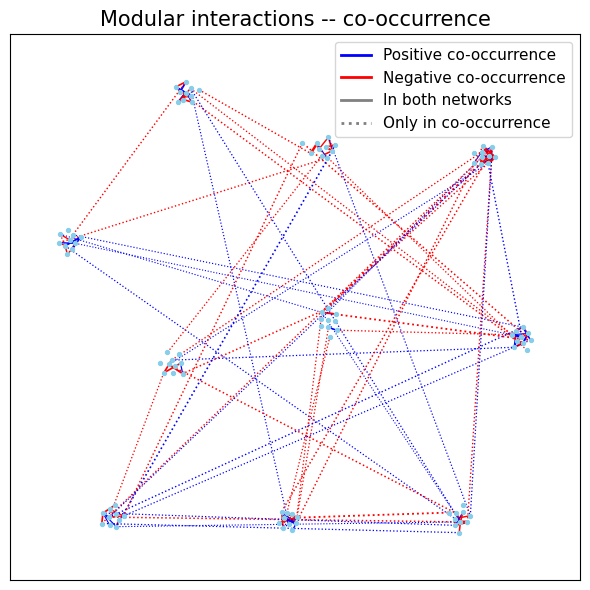

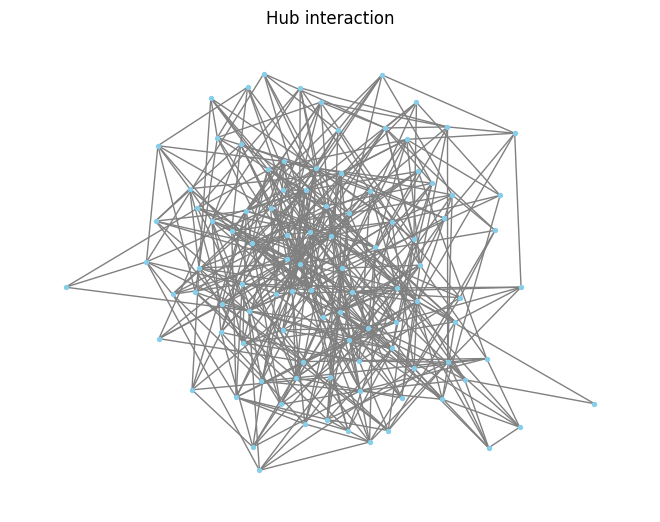

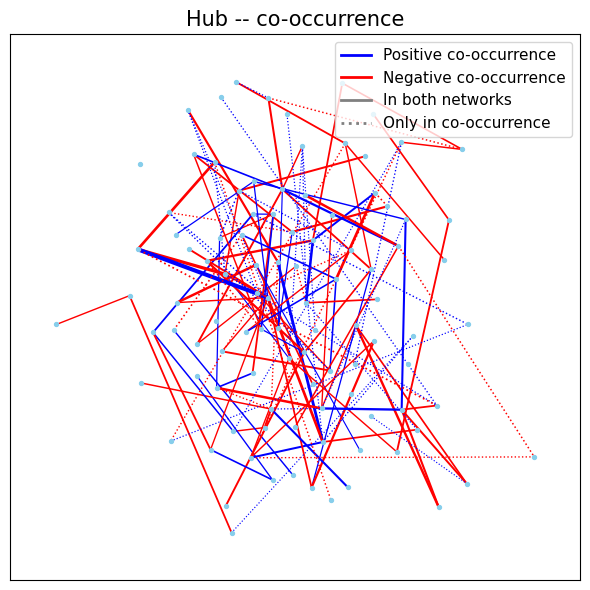

In [203]:
# cutoff based on the covariance of the species with no interactions
pearson_null_flat = pearson_null[np.triu_indices_from(pearson_null, k = 1)]

cutoff_null_95 = (np.quantile(pearson_null_flat, 0.05 / 2), np.quantile(pearson_null_flat, 1-(0.05 / 2)))# consider corr coef significant if greater than this value (95th percentile of null distr)
cutoff_null_99 = (np.quantile(pearson_null_flat, 0.01 / 2), np.quantile(pearson_null_flat, 1-(0.01 / 2))) # consider corr coef significant if greater than this value (95th percentile of null distr)
cutoff_null_999 = (np.quantile(pearson_null_flat, 0.001 / 2), np.quantile(pearson_null_flat, 1-(0.001 / 2))) # consider corr coef significant if greater than this value (95th percentile of null distr)

cutoff_null = cutoff_null_99

#cutoff_null = 0.2

print("cutoff_null")
print(cutoff_null)

network_rand = np.greater(pearson_rand, cutoff_null[1]).astype(int) - np.less(pearson_rand, cutoff_null[0]).astype(int)
np.fill_diagonal(network_rand, 0)
network_mod = np.greater(pearson_mod, cutoff_null[1]).astype(int) - np.less(pearson_mod, cutoff_null[0]).astype(int)
np.fill_diagonal(network_mod, 0)
network_hub = np.greater(pearson_hub, cutoff_null[1]).astype(int) - np.less(pearson_hub, cutoff_null[0]).astype(int)
np.fill_diagonal(network_hub, 0)

# graph from the adjacency matrix
G_rand_coocc = nx.from_numpy_array(network_rand)
G_mod_coocc = nx.from_numpy_array(network_mod)
G_hub_coocc = nx.from_numpy_array(network_hub)

G_rand_inter = nx.from_numpy_array(randMx != 0)
G_mod_inter = nx.from_numpy_array(modMx != 0)
G_hub_inter = nx.from_numpy_array(hubMx != 0)

# normalize correlation matrices for edge widths (same as visualize_net.ipynb)
norm_pearson_rand = pearson_rand / (pearson_rand.max() - pearson_rand.min())
norm_pearson_mod  = pearson_mod  / (pearson_mod.max()  - pearson_mod.min())
norm_pearson_hub  = pearson_hub  / (pearson_hub.max()  - pearson_hub.min())

# compute spring layout positions
pos_rand = nx.spring_layout(G_rand_inter, seed=42)
pos_mod  = nx.spring_layout(G_mod_inter,  seed=42)
pos_hub  = nx.spring_layout(G_hub_inter,  seed=42)

with open('figure_data/rid_networks.pkl', 'wb') as f:
    pickle.dump({
        'network_rand': network_rand, 'network_mod': network_mod, 'network_hub': network_hub,
        'randMx': randMx, 'modMx': modMx, 'hubMx': hubMx,
        'pearson_rand': pearson_rand, 'pearson_mod': pearson_mod, 'pearson_hub': pearson_hub,
        'norm_pearson_rand': norm_pearson_rand, 'norm_pearson_mod': norm_pearson_mod, 'norm_pearson_hub': norm_pearson_hub,
        'pos_rand': pos_rand, 'pos_mod': pos_mod, 'pos_hub': pos_hub,
    }, f)

from matplotlib.lines import Line2D

def draw_coocc_network(G_coocc, G_inter, pos, pearson_norm, title):
    """Draw co-occurrence network with sign-based colors, correlation-based widths,
    and solid/dotted lines depending on whether the edge is also in the interaction network."""
    fig, ax = plt.subplots(figsize=(6, 6))
    nx.draw_networkx_nodes(G_coocc, pos, ax=ax, node_color='skyblue', node_size=8)

    edges = list(G_coocc.edges())
    edge_colors = ['blue' if pearson_norm[u, v] >= 0 else 'red' for u, v in edges]
    edge_widths = [abs(pearson_norm[u, v]) * 5 for u, v in edges]
    edge_styles = ['solid' if G_inter.has_edge(u, v) else 'dotted' for u, v in edges]

    # draw solid and dotted edges separately (networkx requires uniform style per call)
    solid_edges  = [(u, v) for (u, v), s in zip(edges, edge_styles) if s == 'solid']
    dotted_edges = [(u, v) for (u, v), s in zip(edges, edge_styles) if s == 'dotted']

    if solid_edges:
        nx.draw_networkx_edges(G_coocc, pos, ax=ax, edgelist=solid_edges,
            edge_color=[('blue' if pearson_norm[u,v] >= 0 else 'red') for u,v in solid_edges],
            width=[abs(pearson_norm[u,v]) * 10 for u,v in solid_edges],
            style='solid')
    if dotted_edges:
        nx.draw_networkx_edges(G_coocc, pos, ax=ax, edgelist=dotted_edges,
            edge_color=[('blue' if pearson_norm[u,v] >= 0 else 'red') for u,v in dotted_edges],
            width=[abs(pearson_norm[u,v]) * 10 for u,v in dotted_edges],
            style='dotted')

    legend_elements = [
        Line2D([0], [0], color='blue',  lw=2, label='Positive co-occurrence'),
        Line2D([0], [0], color='red',   lw=2, label='Negative co-occurrence'),
        Line2D([0], [0], color='gray',  lw=2, linestyle='solid',  label='In both networks'),
        Line2D([0], [0], color='gray',  lw=2, linestyle='dotted', label='Only in co-occurrence'),
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=11)
    ax.set_title(title, fontsize=15)
    plt.tight_layout()
    plt.show()

# random graphs
nx.draw(G_rand_inter, pos_rand, with_labels=False, node_color='skyblue', node_size=8, edge_color='gray')
plt.title("Random interaction")
plt.show()

draw_coocc_network(G_rand_coocc, G_rand_inter, pos_rand, norm_pearson_rand, "Random interactions -- co-occurrence")

# modular graphs
nx.draw(G_mod_inter, pos_mod, with_labels=False, node_color='skyblue', node_size=8, edge_color='gray')
plt.title("Modular interaction")
plt.show()

draw_coocc_network(G_mod_coocc, G_mod_inter, pos_mod, norm_pearson_mod, "Modular interactions -- co-occurrence")

# hub graphs
nx.draw(G_hub_inter, pos_hub, with_labels=False, node_color='skyblue', node_size=8, edge_color='gray')
plt.title("Hub interaction")
plt.show()

draw_coocc_network(G_hub_coocc, G_hub_inter, pos_hub, norm_pearson_hub, "Hub -- co-occurrence")

In [204]:
# FDR calculation using null_cutoff for Pearson correlation
def calculate_fdr(pearson_mx, pearson_null, cutoff, interact_mx):
    """
    Calculate False Discovery Rate (FDR) for Pearson correlations.
    
    An interaction is considered to exist if it exists in EITHER direction
    (i.e., interact_mx[i,j] != 0 OR interact_mx[j,i] != 0).
    
    FDR = (false positives) / (total discoveries)
    
    Parameters:
    -----------
    pearson_mx : array
        Pearson correlation matrix from actual data
    pearson_null : array
        Pearson correlation matrix from null model (no interactions)
    cutoff : float or tuple
        If float, significance threshold as absolute value (symmetric: |r| > cutoff).
        If tuple (lower, upper), asymmetric thresholds (r > upper OR r < lower).
    interact_mx : array
        The true interaction matrix (can be asymmetric)
    
    Returns:
    --------
    dict with FDR statistics
    """
    # Get upper triangle (excluding diagonal) for both matrices
    triu_idx = np.triu_indices_from(pearson_mx, k=1)
    
    pearson_flat = pearson_mx[triu_idx]
    null_flat = pearson_null[triu_idx]
    
    n_pairs = len(pearson_flat)
    
    # Resolve cutoff to lower/upper bounds
    if isinstance(cutoff, tuple):
        lower_cutoff, upper_cutoff = cutoff
    else:
        lower_cutoff, upper_cutoff = -cutoff, cutoff

    # Create ground truth: interaction exists if present in either direction
    # For each pair (i,j), check if interact_mx[i,j] != 0 OR interact_mx[j,i] != 0
    interact_either_dir = (interact_mx != 0) | (interact_mx.T != 0)
    true_interact_flat = interact_either_dir[triu_idx].astype(int)
    
    # Count discoveries (correlations exceeding cutoff)
    discoveries = (pearson_flat > upper_cutoff) | (pearson_flat < lower_cutoff)
    n_discoveries = np.sum(discoveries)
    
    # Count true positives (discoveries that correspond to true interactions)
    true_positives = np.sum(discoveries & (true_interact_flat == 1))
    
    # Count false positives (discoveries that don't correspond to true interactions)
    false_positives = np.sum(discoveries & (true_interact_flat == 0))
    
    # Count false negatives (true interactions not discovered)
    false_negatives = np.sum(~discoveries & (true_interact_flat == 1))
    
    # Count true negatives
    true_negatives = np.sum(~discoveries & (true_interact_flat == 0))
    
    # FDR = false positives / total discoveries
    if n_discoveries > 0:
        fdr = false_positives / n_discoveries
    else:
        fdr = 0.0
    
    # Also calculate sensitivity (true positive rate) and specificity
    n_true_interactions = np.sum(true_interact_flat)
    n_true_non_interactions = n_pairs - n_true_interactions
    
    sensitivity = true_positives / n_true_interactions if n_true_interactions > 0 else 0.0
    specificity = true_negatives / n_true_non_interactions if n_true_non_interactions > 0 else 0.0
    
    # Also keep null-based estimate for comparison
    null_exceeding = np.sum((null_flat > upper_cutoff) | (null_flat < lower_cutoff))
    null_proportion = null_exceeding / n_pairs
    expected_fp_null = null_proportion * n_pairs
    
    return {
        'cutoff': cutoff,
        'n_pairs': n_pairs,
        'n_discoveries': n_discoveries,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'true_negatives': true_negatives,
        'n_true_interactions': n_true_interactions,
        'fdr': min(fdr, 1.0),
        'sensitivity': sensitivity,
        'specificity': specificity,
        'null_exceeding': null_exceeding,
        'expected_fp_null': expected_fp_null
    }

# Calculate FDR for each matrix type
print("=" * 60)
print("FDR Analysis using null_cutoff =", cutoff_null)
print("(Interaction exists if present in EITHER direction)")
print("=" * 60)

fdr_rand = calculate_fdr(pearson_rand, pearson_null, cutoff_null, randMx)
fdr_mod = calculate_fdr(pearson_mod, pearson_null, cutoff_null, modMx)
fdr_hub = calculate_fdr(pearson_hub, pearson_null, cutoff_null, hubMx)

print(f"\nRandom matrix:")
print(f"  True interactions (either dir): {fdr_rand['n_true_interactions']} / {fdr_rand['n_pairs']} pairs")
print(f"  Discoveries: {fdr_rand['n_discoveries']} (TP={fdr_rand['true_positives']}, FP={fdr_rand['false_positives']})")
print(f"  FDR: {fdr_rand['fdr']:.4f} ({fdr_rand['fdr']*100:.2f}%)")
print(f"  Sensitivity: {fdr_rand['sensitivity']:.4f}, Specificity: {fdr_rand['specificity']:.4f}")

print(f"\nModular matrix:")
print(f"  True interactions (either dir): {fdr_mod['n_true_interactions']} / {fdr_mod['n_pairs']} pairs")
print(f"  Discoveries: {fdr_mod['n_discoveries']} (TP={fdr_mod['true_positives']}, FP={fdr_mod['false_positives']})")
print(f"  FDR: {fdr_mod['fdr']:.4f} ({fdr_mod['fdr']*100:.2f}%)")
print(f"  Sensitivity: {fdr_mod['sensitivity']:.4f}, Specificity: {fdr_mod['specificity']:.4f}")

print(f"\nHub matrix:")
print(f"  True interactions (either dir): {fdr_hub['n_true_interactions']} / {fdr_hub['n_pairs']} pairs")
print(f"  Discoveries: {fdr_hub['n_discoveries']} (TP={fdr_hub['true_positives']}, FP={fdr_hub['false_positives']})")
print(f"  FDR: {fdr_hub['fdr']:.4f} ({fdr_hub['fdr']*100:.2f}%)")
print(f"  Sensitivity: {fdr_hub['sensitivity']:.4f}, Specificity: {fdr_hub['specificity']:.4f}")

# Compare FDR across different cutoffs
print("\n" + "=" * 60)
print("FDR comparison across cutoff thresholds")
print("=" * 60)

for cutoff_name, cutoff_val in [('95th', cutoff_null_95), ('99th', cutoff_null_99), ('99.9th', cutoff_null_999)]:
    cutoff_str = f"({cutoff_val[0]:.4f}, {cutoff_val[1]:.4f})" if isinstance(cutoff_val, tuple) else f"{cutoff_val:.4f}"
    print(f"\nCutoff: {cutoff_name} percentile ({cutoff_str})")
    for name, pearson_mx, interact_mx in [('Random', pearson_rand, randMx), ('Modular', pearson_mod, modMx), ('Hub', pearson_hub, hubMx)]:
        fdr_result = calculate_fdr(pearson_mx, pearson_null, cutoff_val, interact_mx)
        print(f"  {name}: {fdr_result['n_discoveries']} discoveries, TP={fdr_result['true_positives']}, FDR = {fdr_result['fdr']:.4f}, Sens = {fdr_result['sensitivity']:.4f}")

FDR Analysis using null_cutoff = (np.float64(-0.1260611873011524), np.float64(0.10589263515609013))
(Interaction exists if present in EITHER direction)

Random matrix:
  True interactions (either dir): 501 / 4950 pairs
  Discoveries: 130 (TP=77, FP=53)
  FDR: 0.4077 (40.77%)
  Sensitivity: 0.1537, Specificity: 0.9881

Modular matrix:
  True interactions (either dir): 358 / 4950 pairs
  Discoveries: 137 (TP=89, FP=48)
  FDR: 0.3504 (35.04%)
  Sensitivity: 0.2486, Specificity: 0.9895

Hub matrix:
  True interactions (either dir): 478 / 4950 pairs
  Discoveries: 132 (TP=93, FP=39)
  FDR: 0.2955 (29.55%)
  Sensitivity: 0.1946, Specificity: 0.9913

FDR comparison across cutoff thresholds

Cutoff: 95th percentile ((-0.1004, 0.0799))
  Random: 337 discoveries, TP=134, FDR = 0.6024, Sens = 0.2675
  Modular: 328 discoveries, TP=132, FDR = 0.5976, Sens = 0.3687
  Hub: 361 discoveries, TP=159, FDR = 0.5596, Sens = 0.3326

Cutoff: 99th percentile ((-0.1261, 0.1059))
  Random: 130 discoveries, TP=7

3.2 compute proportion of links within and between clusters 

4. Runs a clustering algorithm to find clusters in the matrix

In [207]:
# louvain algorithm for clustering into communities
rand_clust_coocc = nx.community.louvain_communities(G_rand_coocc)
mod_clust_coocc = nx.community.louvain_communities(G_mod_coocc)
hub_clust_coocc = nx.community.louvain_communities(G_hub_coocc)

rand_clust_inter = nx.community.louvain_communities(G_rand_inter)
mod_clust_inter = nx.community.louvain_communities(G_mod_inter)
hub_clust_inter = nx.community.louvain_communities(G_hub_inter)

# greedy alg
rand_clust_coocc_gr = nx.community.greedy_modularity_communities(G_rand_coocc)
mod_clust_coocc_gr = nx.community.greedy_modularity_communities(G_mod_coocc)
hub_clust_coocc_gr = nx.community.greedy_modularity_communities(G_hub_coocc)

rand_clust_inter_gr = nx.community.greedy_modularity_communities(G_rand_inter)
mod_clust_inter_gr = nx.community.greedy_modularity_communities(G_mod_inter)
hub_clust_inter_gr = nx.community.greedy_modularity_communities(G_hub_inter)


5. Tests to see if the clusters are similar to the original modules

In [208]:
reload(metrics_and_plotting)

# number of pairs in cooccurrence clusters that are also clustered together in interactions clusters, and vice versa
print("louvain algorithm: number of pairs in cooccurrence clusters that are also clustered together in interactions clusters, and vice versa")
rand_clust_sim = metrics_and_plotting.test_cluster_similarity(rand_clust_coocc, rand_clust_inter)
mod_clust_sim = metrics_and_plotting.test_cluster_similarity(mod_clust_coocc, mod_clust_inter)
hub_clust_sim = metrics_and_plotting.test_cluster_similarity(hub_clust_coocc, hub_clust_inter)

print("Random cluster similarity:")
print(rand_clust_sim)

print("Modular cluster similarity:")
print(mod_clust_sim)

print("Hub cluster similarity:")
print(hub_clust_sim)
print()

# now for the greedy algorithm
print("greedy algorithm: number of pairs in cooccurrence clusters that are also clustered together in interactions clusters, and vice versa")
rand_clust_sim = metrics_and_plotting.test_cluster_similarity(rand_clust_coocc_gr, rand_clust_inter_gr)
mod_clust_sim = metrics_and_plotting.test_cluster_similarity(mod_clust_coocc_gr, mod_clust_inter_gr)
hub_clust_sim = metrics_and_plotting.test_cluster_similarity(hub_clust_coocc_gr, hub_clust_inter_gr)

print("Random cluster similarity:")
print(rand_clust_sim)

print("Modular cluster similarity:")
print(mod_clust_sim)

print("Hub cluster similarity:")
print(hub_clust_sim)

louvain algorithm: number of pairs in cooccurrence clusters that are also clustered together in interactions clusters, and vice versa
Random cluster similarity:
(94, 7908, 480, 1418, 0.8082828282828283)
Modular cluster similarity:
(148, 8686, 314, 752, 0.8923232323232323)
Hub cluster similarity:
(120, 7858, 378, 1544, 0.8058585858585858)

greedy algorithm: number of pairs in cooccurrence clusters that are also clustered together in interactions clusters, and vice versa
Random cluster similarity:
(328, 6878, 888, 1806, 0.7278787878787879)
Modular cluster similarity:
(394, 8502, 498, 506, 0.8985858585858586)
Hub cluster similarity:
(230, 7268, 952, 1450, 0.7573737373737374)


6. ROC curve for edges being in or out of a module (is pearson correlation a good predictor of edges in or out of module?). ROC curve for whether NX centrality is a good predictor of whether a node is a hub taxon.

AUC for interact strength factor = 0.3333333333333333: 0.775629
AUC for interact strength factor = 0.2: 0.672859
AUC for interact strength factor = 0.1: 0.554545


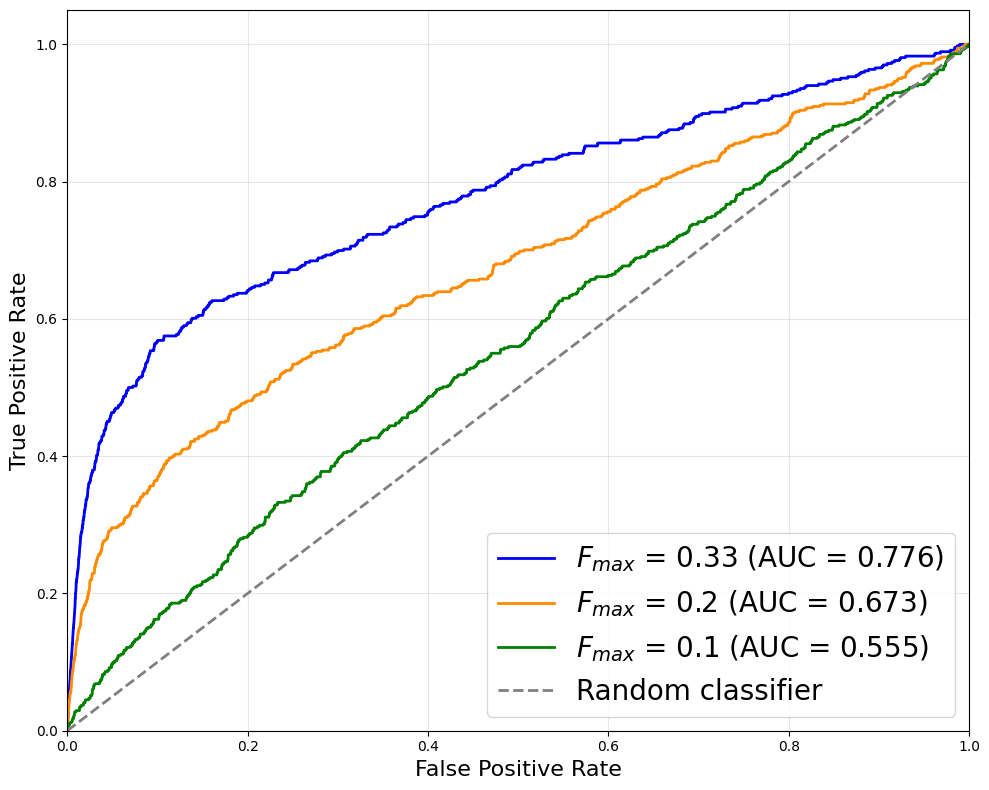

In [209]:
# ROC curve for directly predicting edges 
interactFactorL = [1/3, 1/5, 1/10]

colors = ['blue', 'darkorange', 'green']

_roc_rand_data = []

plt.figure(figsize=(10, 8))

for iii in range(len(interactFactorL)):    
    interactStren_test = np.mean(alpha) * interactFactorL[iii]
    # Generate random matrix with this interaction strength
    randMx_test = metaCommunityMx.getRandomMatrix(maxInteractionStrength=interactStren_test, pPositive=pPositive, pInteract=pInteract, nSpecies=nSpec, pBidirectional=0)
    
    # Run simulation with this matrix
    rand_res_test = community_sim.simulate_coOccurrence(samplesize, numtrials, 
        a=randMx_test, b=b, alpha=alpha, tmax=100, y0=None)
    
    null_cutoff = run_cooccurrence.get_null_cutoff(nSpec = nSpec, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, pval_alpha = 0.01, tmax = 100)

    rand_coAbd_test = np.round(rand_res_test[0], 0)
    
    # Calculate Pearson correlation
    pearson_rand_test = np.corrcoef(rand_coAbd_test, rowvar=False)
    
    # Prepare data for ROC curve
    binary_rand_test = (randMx_test != 0).astype(int)
    pearson_rand_abs_test = np.abs(pearson_rand_test)
    
    # Remove diagonal and flatten
    mask = ~np.eye(binary_rand_test.shape[0], dtype=bool)
    binary_rand_flat_test = binary_rand_test[mask]
    pearson_rand_flat_test = pearson_rand_abs_test[mask]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = metrics.roc_curve(binary_rand_flat_test, pearson_rand_flat_test)
    roc_auc = metrics.auc(fpr, tpr)
    
    _roc_rand_data.append({'interactFactor': interactFactorL[iii], 'fpr': fpr, 'tpr': tpr, 'roc_auc': roc_auc})
    
    # Plot ROC curve
    plt.plot(fpr, tpr, color=colors[iii], lw=2, 
             label=f'$F_{{max}}$ = {np.round(interactFactorL[iii],2)} (AUC = {roc_auc:.3f})')
    
    print(f"AUC for interact strength factor = {interactFactorL[iii]}: {roc_auc:.6f}")

with open('figure_data/rid_roc_rand.pkl', 'wb') as f:
    pickle.dump({'roc_data': _roc_rand_data, 'interactFactorL': interactFactorL, 'colors': colors}, f)

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
#plt.title('ROC Curves - Direct Edge Prediction\nComparison Across Interaction Strengths', fontsize=14)
plt.legend(loc="lower right", fontsize=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

0.000457648001260952 0.5 100 0.55 0 10
Direct edge AUC for Interaction strength factor = 0.33: 0.820172
Within-module AUC for Interaction strength factor = 0.33: 0.766740
0.0002745888007565712 0.5 100 0.55 0 10
Direct edge AUC for Interaction strength factor = 0.2: 0.726168
Within-module AUC for Interaction strength factor = 0.2: 0.678595
0.0001372944003782856 0.5 100 0.55 0 10
Direct edge AUC for Interaction strength factor = 0.1: 0.580677
Within-module AUC for Interaction strength factor = 0.1: 0.558384


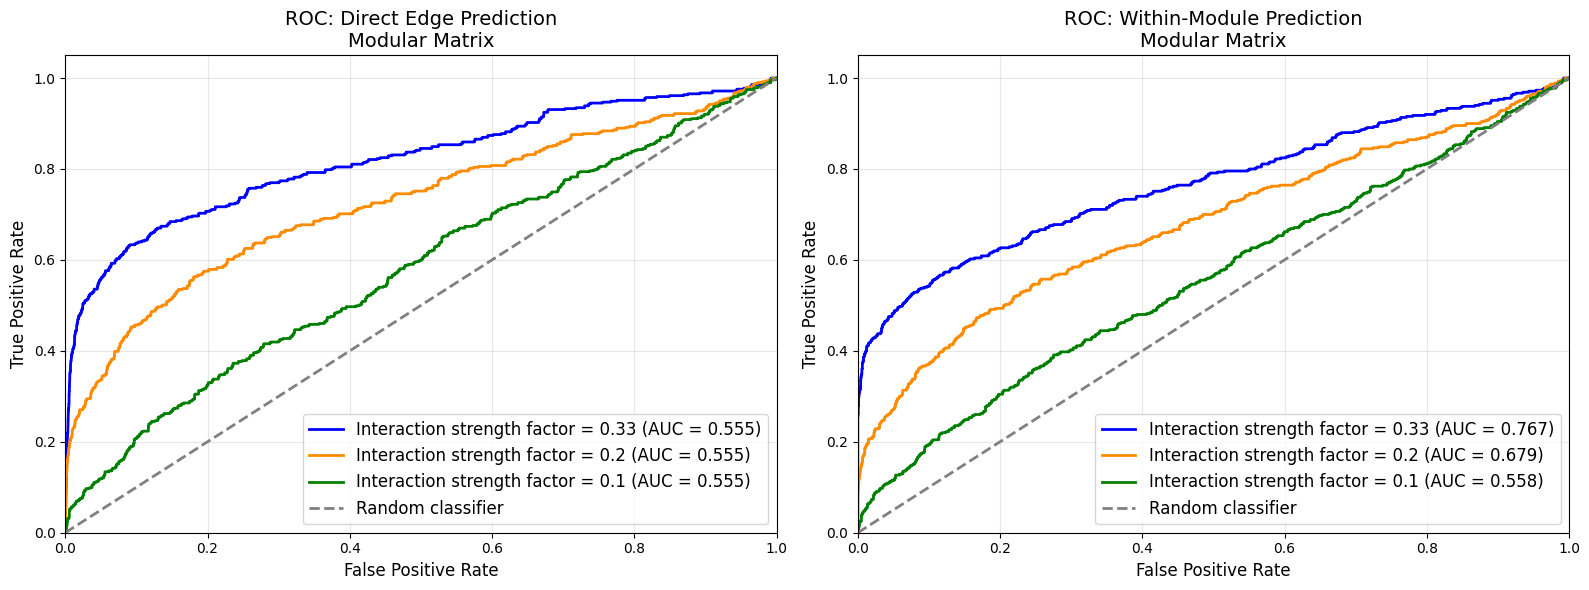

In [210]:
# Direct edges vs Within-module prediction
interactFactorL = [1/3, 1/5, 1/10]
colors = ['blue', 'darkorange', 'green']

_roc_mod_data = []

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for iii in range(len(interactFactorL)):
    interactStren_test = np.mean(alpha) * interactFactorL[iii]
    print(interactStren_test,
        pPositive,
        nSpec,
        pWithinMod,
        0,
        nModules)
    # Generate modular matrix with this interaction strength
    modMx_test = metaCommunityMx.generateModularMatrix(
        maxInteractionStrength=interactStren_test,
        pPositive=pPositive,
        nSpecies=nSpec,
        pWithinMod=pWithinMod,
        pBetweenMod=0,
        nModules=nModules
    )

    # Run simulation with this matrix
    mod_res_test = community_sim.simulate_coOccurrence(samplesize, numtrials,
        a=modMx_test, b=b, alpha=alpha, tmax=100, y0=None)

    mod_coAbd_test = np.round(mod_res_test[0], 0)

    # Calculate Pearson correlation
    pearson_mod_test = np.corrcoef(mod_coAbd_test, rowvar=False)
    pearson_mod_abs_test = np.abs(pearson_mod_test)

    # === PLOT 1: Direct edge prediction ===
    # Prepare data for ROC curve - direct edges
    binary_mod_test = (modMx_test != 0).astype(int)

    # Remove diagonal and flatten
    mask = ~np.eye(binary_mod_test.shape[0], dtype=bool)
    binary_mod_flat_test = binary_mod_test[mask]
    pearson_mod_flat_test = pearson_mod_abs_test[mask]

    # Calculate ROC curve for direct edges
    fpr_edge, tpr_edge, _ = metrics.roc_curve(binary_mod_flat_test, pearson_mod_flat_test)
    roc_auc_edge = metrics.auc(fpr_edge, tpr_edge)

    # Plot ROC curve for direct edges
    ax1.plot(fpr_edge, tpr_edge, color=colors[iii], lw=2,
            label=f'Interaction strength factor = {np.round(interactFactorL[iii], 2)} (AUC = {roc_auc:.3f})')

    print(f"Direct edge AUC for Interaction strength factor = {np.round(interactFactorL[iii], 2)}: {roc_auc_edge:.6f}")

    # === PLOT 2: Within-module prediction ===
    # Create binary matrix for within vs between module
    module_assignments = np.repeat(np.arange(nModules), nSpec // nModules)
    within_module_matrix = np.zeros((nSpec, nSpec), dtype=int)
    for i in range(nSpec):
        for j in range(nSpec):
            if i != j and module_assignments[i] == module_assignments[j]:
                within_module_matrix[i, j] = 1

    # Flatten for ROC curve
    within_module_flat = within_module_matrix[mask]

    # Calculate ROC curve for within-module prediction
    fpr_mod, tpr_mod, _ = metrics.roc_curve(within_module_flat, pearson_mod_flat_test)
    roc_auc_mod = metrics.auc(fpr_mod, tpr_mod)

    # Plot ROC curve for within-module prediction
    ax2.plot(fpr_mod, tpr_mod, color=colors[iii], lw=2,
             label=f'Interaction strength factor = {np.round(interactFactorL[iii], 2)} (AUC = {roc_auc_mod:.3f})')

    print(f"Within-module AUC for Interaction strength factor = {np.round(interactFactorL[iii],2)}: {roc_auc_mod:.6f}")

    _roc_mod_data.append({
        'interactFactor': interactFactorL[iii],
        'fpr_edge': fpr_edge, 'tpr_edge': tpr_edge, 'auc_edge': roc_auc_edge,
        'fpr_mod': fpr_mod, 'tpr_mod': tpr_mod, 'auc_mod': roc_auc_mod,
    })

with open('figure_data/rid_roc_mod.pkl', 'wb') as f:
    pickle.dump({'roc_data': _roc_mod_data, 'interactFactorL': interactFactorL, 'colors': colors}, f)

# Plot diagonal line (random classifier) on both plots
ax1.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random classifier')
ax2.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random classifier')

# Configure first plot (direct edges)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC: Direct Edge Prediction\nModular Matrix', fontsize=14)
ax1.legend(loc="lower right", fontsize=12)
ax1.grid(True, alpha=0.3)

# Configure second plot (within-module)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC: Within-Module Prediction\nModular Matrix', fontsize=14)
ax2.legend(loc="lower right", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Plot the correlation between each pair of nodes in the co-occurrnece network versus the interaction strength.

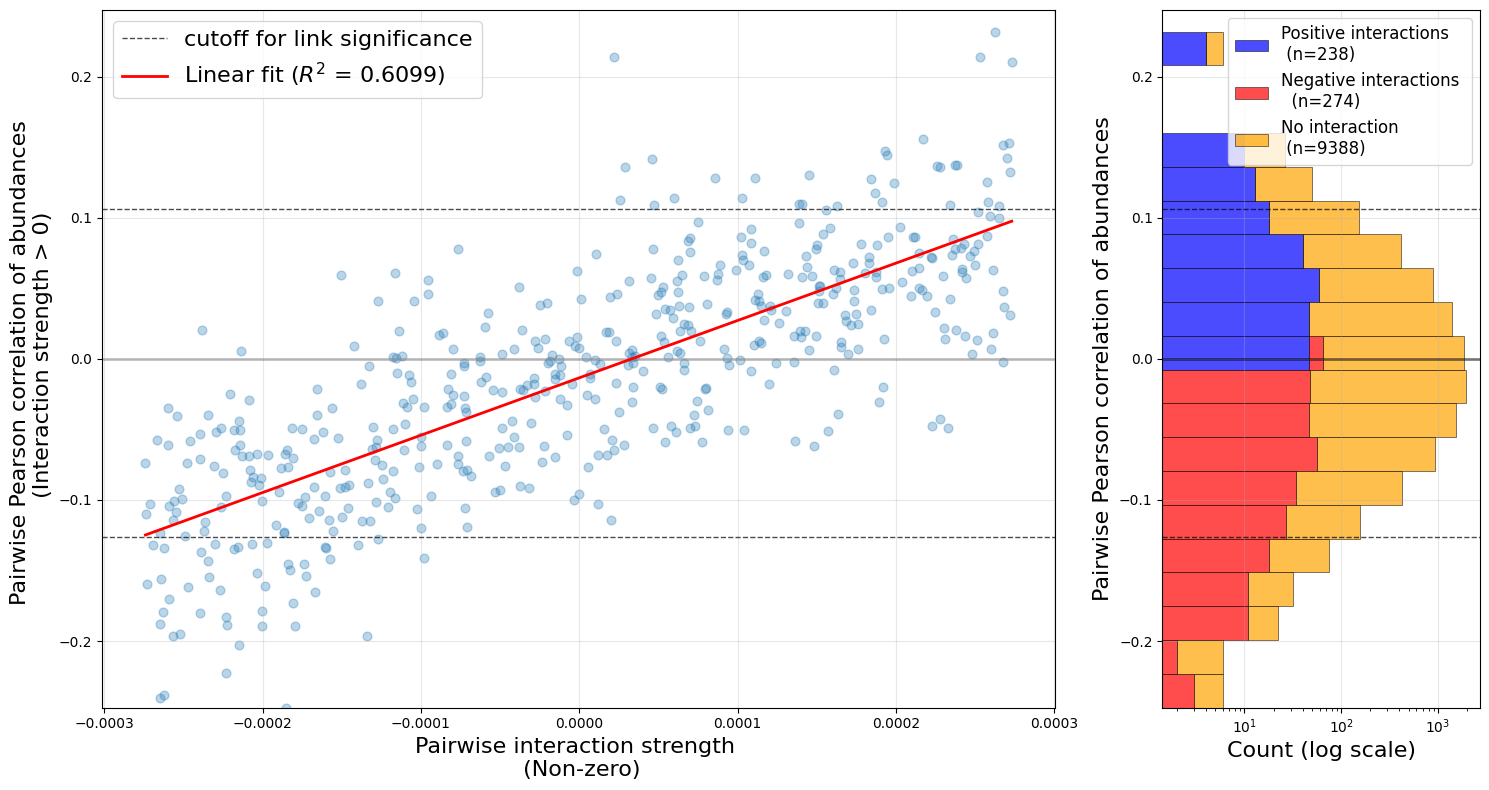

In [211]:
import pickle, os
os.makedirs('figure_data', exist_ok=True)
with open('figure_data/rid_corr_vs_interact.pkl', 'wb') as f:
    pickle.dump({
        'pearson_rand': pearson_rand,
        'randMx': randMx,
        'cutoff_null': cutoff_null,
    }, f)

reload(metrics_and_plotting)
# stats_rand = metrics_and_plotting.plot_corr_vs_interact2(corrMx = pearson_rand, interactMx = randMx, cutoff_null_95 = cutoff_null_99, title = "Random interactions")
# stats_modular = metrics_and_plotting.plot_corr_vs_interact2(corrMx = pearson_mod, interactMx = modMx, cutoff_null_95 = cutoff_null_99, title = "Modular interactions")
# stats_hub = metrics_and_plotting.plot_corr_vs_interact2(corrMx = pearson_hub, interactMx = hubMx, cutoff_null_95 = cutoff_null_99, title = "Hub interactions")

stats_rand = metrics_and_plotting.plot_corr_vs_interact(corrMx = pearson_rand, interactMx = randMx, cutoff_null_95 = cutoff_null, title = "")


Running null simulation for cutoff...
Null cutoffs (99% CI): lower=-0.1258, upper=0.1090

--- Iteration 1/5 ---
  Hub...
  Modular...
  Random...

--- Iteration 2/5 ---
  Hub...
  Modular...
  Random...

--- Iteration 3/5 ---
  Hub...
  Modular...
  Random...

--- Iteration 4/5 ---
  Hub...
  Modular...
  Random...

--- Iteration 5/5 ---
  Hub...
  Modular...
  Random...

Done aggregating.


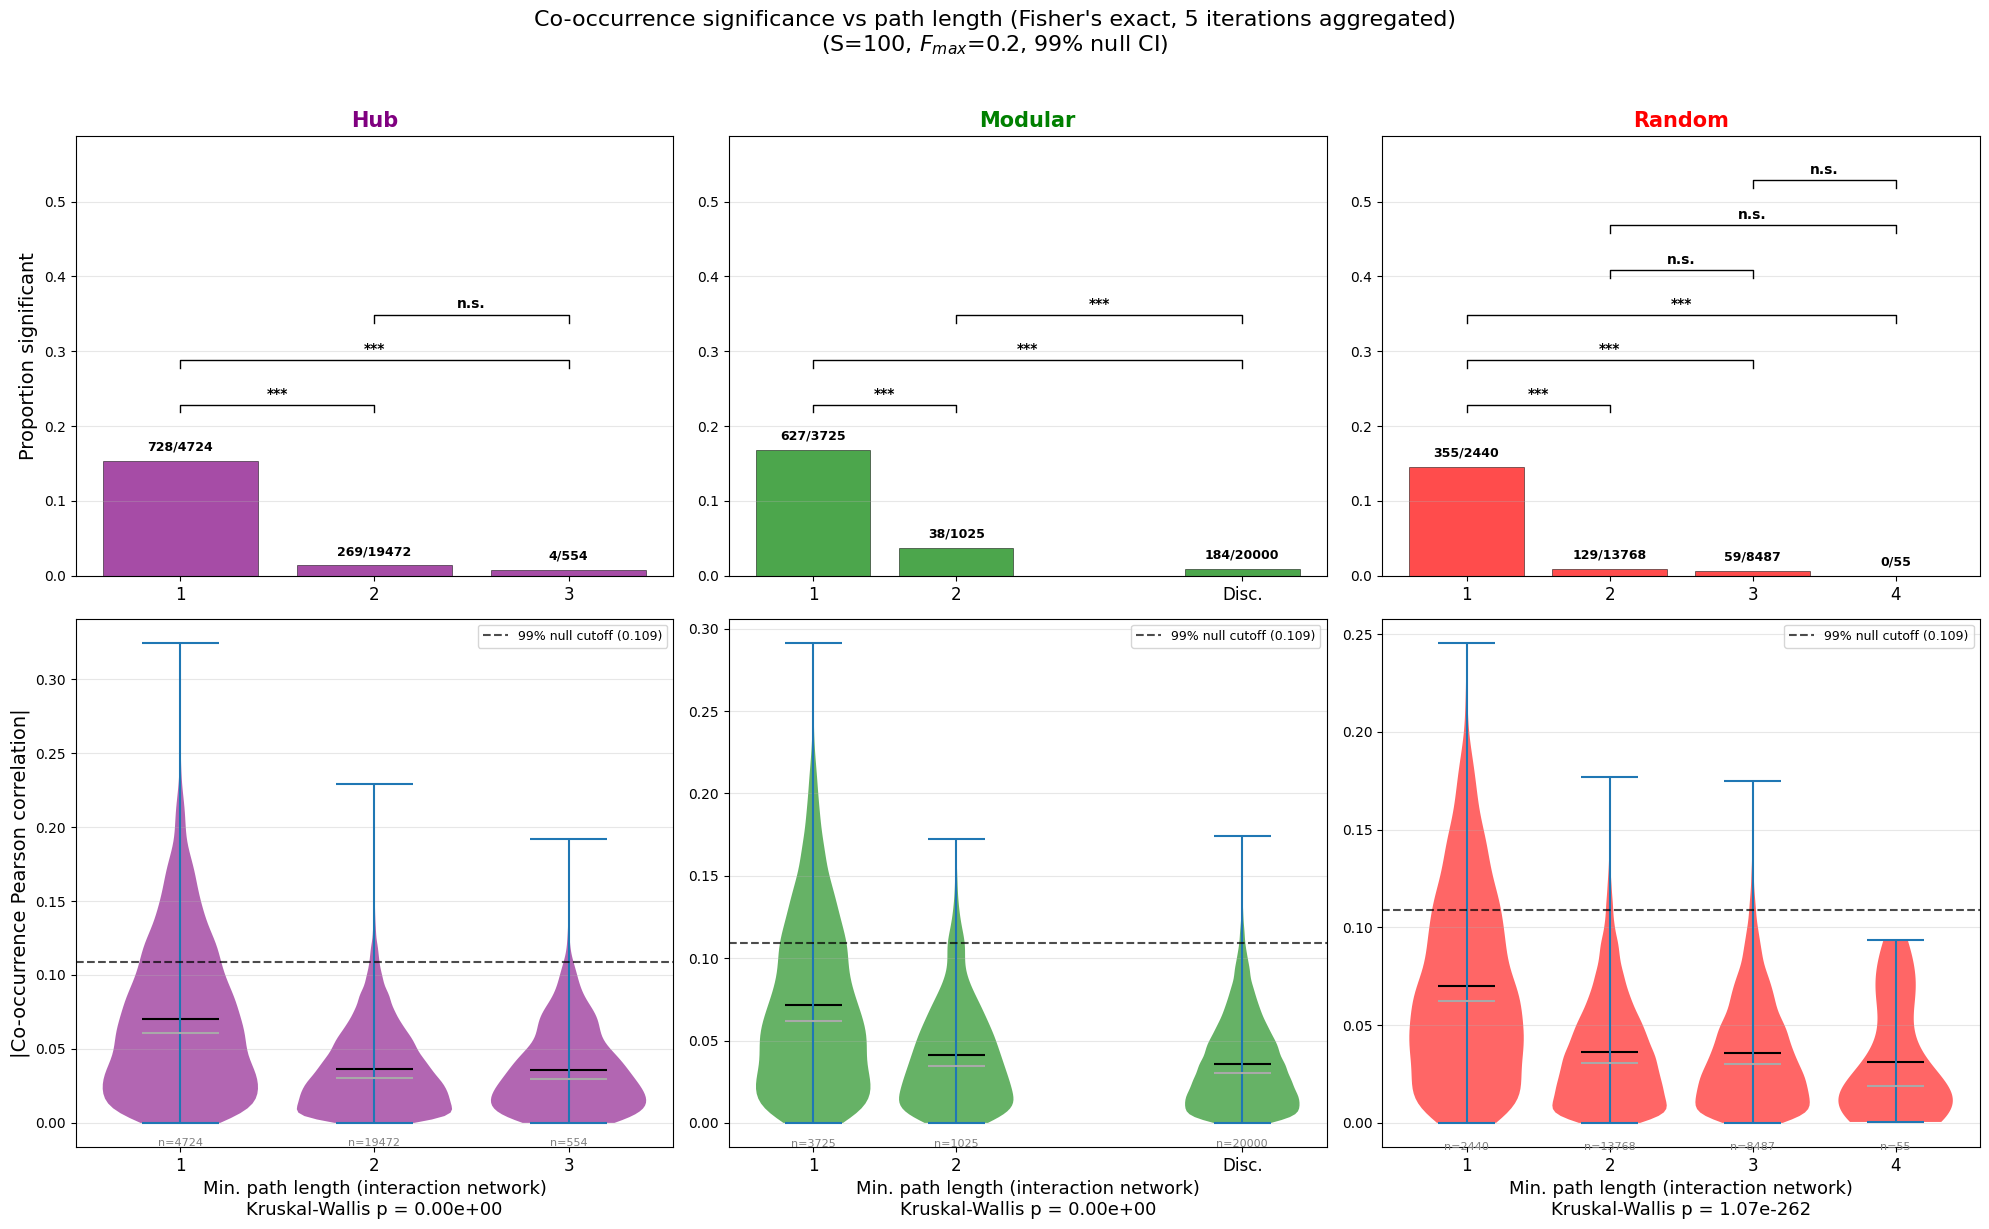

In [212]:
# Proportion of significant co-occurrence edges vs path length
# Aggregated over 5 iterations per network type for higher power

from scipy.stats import kruskal, mannwhitneyu, fisher_exact
from itertools import combinations

n_iterations_pl = 5

# Parameters from degree_sequence_rank.ipynb
nSpec_ds = 100
interactFactor_ds = 1/5
pPositive_ds = 0.1
alpha_ds = 0.001
interactStren_ds = alpha_ds * interactFactor_ds
samplesize_ds = nSpec_ds // 2
numtrials_ds = 500
cutoffalpha_ds = 0.01
nModules_ds = 5

modHubParms_ds = metaCommunityMx.hubMxMatching(nSpec_ds, nModules_ds, pInteractRandom=10 / ((nSpec_ds - 1)))

# Get null cutoffs (99% CI) once
print("Running null simulation for cutoff...")
b_ds = np.ones(nSpec_ds) - np.random.uniform(low=0, high=0.1, size=(nSpec_ds))
null_cutoffs_ds = run_cooccurrence.get_null_cutoff(nSpec=nSpec_ds, alpha=alpha_ds, spsamplesize=samplesize_ds,
                                                    numtrials=numtrials_ds, b=b_ds, pval_alpha=0.01, tmax=200)
lower_cutoff_ds, upper_cutoff_ds = null_cutoffs_ds
print(f"Null cutoffs (99% CI): lower={lower_cutoff_ds:.4f}, upper={upper_cutoff_ds:.4f}")

# Aggregated counts: path_length -> {'total': int, 'significant': int, 'abs_corrs': list}
agg_counts_hub = {}
agg_counts_mod = {}
agg_counts_rand = {}

def add_to_agg(agg, path_lengths, pearson_mx, nSpec, lower_cut, upper_cut):
    for i in range(nSpec):
        for j in range(i + 1, nSpec):
            corr = pearson_mx[i, j]
            if np.isnan(corr):
                continue
            if j in path_lengths[i]:
                pl = path_lengths[i][j]
            else:
                pl = -1
            if pl not in agg:
                agg[pl] = {'total': 0, 'significant': 0, 'abs_corrs': []}
            agg[pl]['total'] += 1
            agg[pl]['abs_corrs'].append(np.abs(corr))
            if corr <= lower_cut or corr >= upper_cut:
                agg[pl]['significant'] += 1

for iteration in range(n_iterations_pl):
    print(f"\n--- Iteration {iteration + 1}/{n_iterations_pl} ---")
    b_iter = np.ones(nSpec_ds) - np.random.uniform(low=0, high=0.1, size=(nSpec_ds))
    
    # Generate networks
    G_random_iter, mx_random_iter = metaCommunityMx.getPowerOrExpMatrix(nSpec_ds, interactStren_ds, type="random", expected_degree=10, pPositive=pPositive_ds)
    mx_mod_iter = metaCommunityMx.generateModularMatrix(interactStren_ds, pPositive_ds, nSpec_ds, modHubParms_ds["pWithinMod"], modHubParms_ds["pBetweenMod"], nModules_ds)
    mx_hub_iter = metaCommunityMx.generateHubMatrix(interactStren_ds, pPositive_ds, nSpec_ds, modHubParms_ds["pWithinModHub"], modHubParms_ds["pBetweenModHub"], nModules_ds, modHubParms_ds["pHub"])
    
    G_mod_iter = nx.from_numpy_array(mx_mod_iter != 0)
    G_hub_iter = nx.from_numpy_array(mx_hub_iter != 0)
    
    # Run co-occurrence simulations
    print("  Hub...")
    sim_hub_iter = community_sim.simulate_coOccurrence(samplesize_ds, numtrials_ds, a=mx_hub_iter, b=b_iter, alpha=alpha_ds, tmax=200, y0=None)
    pearson_hub_iter = np.corrcoef(np.round(sim_hub_iter[0], 0), rowvar=False)
    
    print("  Modular...")
    sim_mod_iter = community_sim.simulate_coOccurrence(samplesize_ds, numtrials_ds, a=mx_mod_iter, b=b_iter, alpha=alpha_ds, tmax=200, y0=None)
    pearson_mod_iter = np.corrcoef(np.round(sim_mod_iter[0], 0), rowvar=False)
    
    print("  Random...")
    sim_rand_iter = community_sim.simulate_coOccurrence(samplesize_ds, numtrials_ds, a=mx_random_iter, b=b_iter, alpha=alpha_ds, tmax=200, y0=None)
    pearson_rand_iter = np.corrcoef(np.round(sim_rand_iter[0], 0), rowvar=False)
    
    # Compute path lengths
    pl_hub_iter = dict(nx.all_pairs_shortest_path_length(G_hub_iter))
    pl_mod_iter = dict(nx.all_pairs_shortest_path_length(G_mod_iter))
    pl_rand_iter = dict(nx.all_pairs_shortest_path_length(G_random_iter))
    
    # Aggregate
    add_to_agg(agg_counts_hub, pl_hub_iter, pearson_hub_iter, nSpec_ds, lower_cutoff_ds, upper_cutoff_ds)
    add_to_agg(agg_counts_mod, pl_mod_iter, pearson_mod_iter, nSpec_ds, lower_cutoff_ds, upper_cutoff_ds)
    add_to_agg(agg_counts_rand, pl_rand_iter, pearson_rand_iter, nSpec_ds, lower_cutoff_ds, upper_cutoff_ds)

print("\nDone aggregating.")

with open('figure_data/rid_path_length.pkl', 'wb') as f:
    pickle.dump({
        'agg_counts_hub': agg_counts_hub,
        'agg_counts_mod': agg_counts_mod,
        'agg_counts_rand': agg_counts_rand,
        'upper_cutoff_ds': upper_cutoff_ds,
        'n_iterations_pl': n_iterations_pl,
        'interactFactor_ds': interactFactor_ds,
        'nSpec_ds': nSpec_ds,
    }, f)

# Pairwise Fisher's exact test
def pairwise_fisher_test(counts, k1, k2):
    s1, t1 = counts[k1]['significant'], counts[k1]['total']
    s2, t2 = counts[k2]['significant'], counts[k2]['total']
    table = np.array([[s1, t1 - s1],
                      [s2, t2 - s2]])
    _, pval = fisher_exact(table)
    return pval

# Helper to format p-values as significance stars
def pval_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

# Plot: 2 rows x 3 columns
fig, axes = plt.subplots(2, 3, figsize=(20, 12), gridspec_kw={'height_ratios': [1, 1.2]})

titles_sig = ['Hub', 'Modular', 'Random']
all_counts = [agg_counts_hub, agg_counts_mod, agg_counts_rand]
colors_sig = ['purple', 'green', 'red']

# Pre-compute shared y-axis limit for top row bar plots
_global_max_prop = 0
_global_max_nkeys = 0
for _counts in all_counts:
    _skeys = sorted([k for k in _counts.keys() if k > 0])
    if -1 in _counts:
        _skeys.append(-1)
    _props = [_counts[k]['significant'] / _counts[k]['total'] for k in _skeys]
    if _props:
        _global_max_prop = max(_global_max_prop, max(_props))
    _global_max_nkeys = max(_global_max_nkeys, len(_skeys))
_bracket_step = 0.06
_global_bracket_y = _global_max_prop + 0.06
_n_pairwise = _global_max_nkeys * (_global_max_nkeys - 1) // 2
_global_bar_ylim = _global_bracket_y + _n_pairwise * _bracket_step

for col, (counts, title, color) in enumerate(zip(all_counts, titles_sig, colors_sig)):
    sorted_keys = sorted([k for k in counts.keys() if k > 0])
    if -1 in counts:
        sorted_keys.append(-1)
    
    labels = [str(k) if k > 0 else 'Disc.' for k in sorted_keys]
    positions = list(range(len(sorted_keys)))
    if -1 in counts and len(positions) > 1:
        positions[-1] = positions[-2] + 2
    
    # --- Top row: proportion significant ---
    ax_bar = axes[0, col]
    proportions = [counts[k]['significant'] / counts[k]['total'] for k in sorted_keys]
    totals = [counts[k]['total'] for k in sorted_keys]
    n_sig = [counts[k]['significant'] for k in sorted_keys]
    
    bars = ax_bar.bar(positions, proportions, color=color, alpha=0.7, width=0.8, edgecolor='black', linewidth=0.5)
    
    # Annotate bars with n_sig / n_total
    for idx, (pos, prop, ns, nt) in enumerate(zip(positions, proportions, n_sig, totals)):
        ax_bar.text(pos, prop + 0.01, f'{ns}/{nt}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax_bar.set_title(title, fontsize=15, fontweight='bold', color=color)
    
    # All pairwise Fisher's exact tests
    bracket_idx = 0
    for i_key, j_key in combinations(range(len(sorted_keys)), 2):
        k1, k2 = sorted_keys[i_key], sorted_keys[j_key]
        if counts[k1]['total'] > 0 and counts[k2]['total'] > 0:
            pw_pval = pairwise_fisher_test(counts, k1, k2)
            stars = pval_to_stars(pw_pval)
            
            p1, p2 = positions[i_key], positions[j_key]
            y_bar = _global_bracket_y + bracket_idx * _bracket_step
            
            ax_bar.plot([p1, p1, p2, p2], [y_bar - 0.01, y_bar, y_bar, y_bar - 0.01],
                        color='black', linewidth=1)
            ax_bar.text((p1 + p2) / 2, y_bar + 0.005, stars,
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
            bracket_idx += 1
    
    ax_bar.set_xticks(positions)
    ax_bar.set_xticklabels(labels, fontsize=12)
    ax_bar.set_ylabel('Proportion significant' if col == 0 else '', fontsize=14)
    ax_bar.set_ylim(0, _global_bar_ylim)
    ax_bar.grid(alpha=0.3, axis='y')
    
    # --- Bottom row: violin of ALL |correlations| ---
    ax_viol = axes[1, col]
    violin_data = [counts[k]['abs_corrs'] for k in sorted_keys]
    
    parts = ax_viol.violinplot(violin_data, positions=positions, showmeans=True, showmedians=True, widths=0.8)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    parts['cmeans'].set_color('black')
    parts['cmedians'].set_color('darkgray')
    
    # Draw significance threshold line
    ax_viol.axhline(y=upper_cutoff_ds, color='black', linestyle='--', alpha=0.7, linewidth=1.5, label=f'99% null cutoff ({upper_cutoff_ds:.3f})')
    ax_viol.legend(fontsize=9, loc='upper right')
    
    # Kruskal-Wallis
    groups_for_test = [counts[k]['abs_corrs'] for k in sorted_keys if len(counts[k]['abs_corrs']) > 1]
    if len(groups_for_test) >= 2:
        kw_stat, kw_pval = kruskal(*groups_for_test)
        ax_viol.set_xlabel(f'Min. path length (interaction network)\nKruskal-Wallis p = {kw_pval:.2e}', fontsize=13)
    else:
        ax_viol.set_xlabel('Min. path length (interaction network)', fontsize=13)
    
    # Sample sizes
    all_vals = [v for group in violin_data for v in group]
    y_min = min(all_vals) if all_vals else 0
    for idx, k in enumerate(sorted_keys):
        ax_viol.text(positions[idx], y_min - 0.01, f'n={counts[k]["total"]}',
                     ha='center', va='top', fontsize=8, color='gray')
    
    ax_viol.set_xticks(positions)
    ax_viol.set_xticklabels(labels, fontsize=12)
    ax_viol.set_ylabel('|Co-occurrence Pearson correlation|' if col == 0 else '', fontsize=14)
    ax_viol.grid(alpha=0.3, axis='y')

plt.suptitle(f'Co-occurrence significance vs path length (Fisher\'s exact, {n_iterations_pl} iterations aggregated)\n(S={nSpec_ds}, $F_{{max}}$={interactFactor_ds}, 99% null CI)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()